**15.8. Project 8. Time Series Forecasting**

**Dataset:** `airline-passengers.csv`

To model and forecast monthly airline passenger demand using historical data to understand long term growth and recurring seasonal travel patterns.

>**Time series forecasting** predicts future values by learning patterns like trend and seasonality from historical, time ordered data.
Unlike regular ML, the order of data matters, and past values directly influence future predictions.

In [1]:
# installing the dependencies
%pip install -q numpy pandas matplotlib statsmodels scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# importing the required dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

In [8]:
# load data
df = pd.read_csv("airline-passengers.csv")
print("Dataset shape:", df.shape)
display(df.head(10))
display(df.tail(10))

Dataset shape: (144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


,Month,Passengers
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [9]:
# basic dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [10]:
# check missing values
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

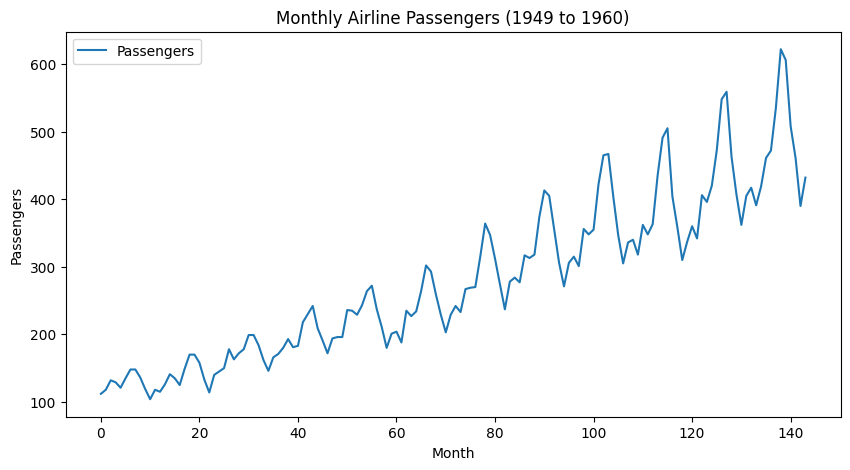

In [12]:
# plot time series
plt.figure(figsize=(10,5))
plt.plot(df["Passengers"], label="Passengers")
plt.title("Monthly Airline Passengers (1949 to 1960)")
plt.ylabel("Passengers")
plt.xlabel("Month")
plt.legend()
plt.show()

>Inference: Seasonality is clearly visible in the data

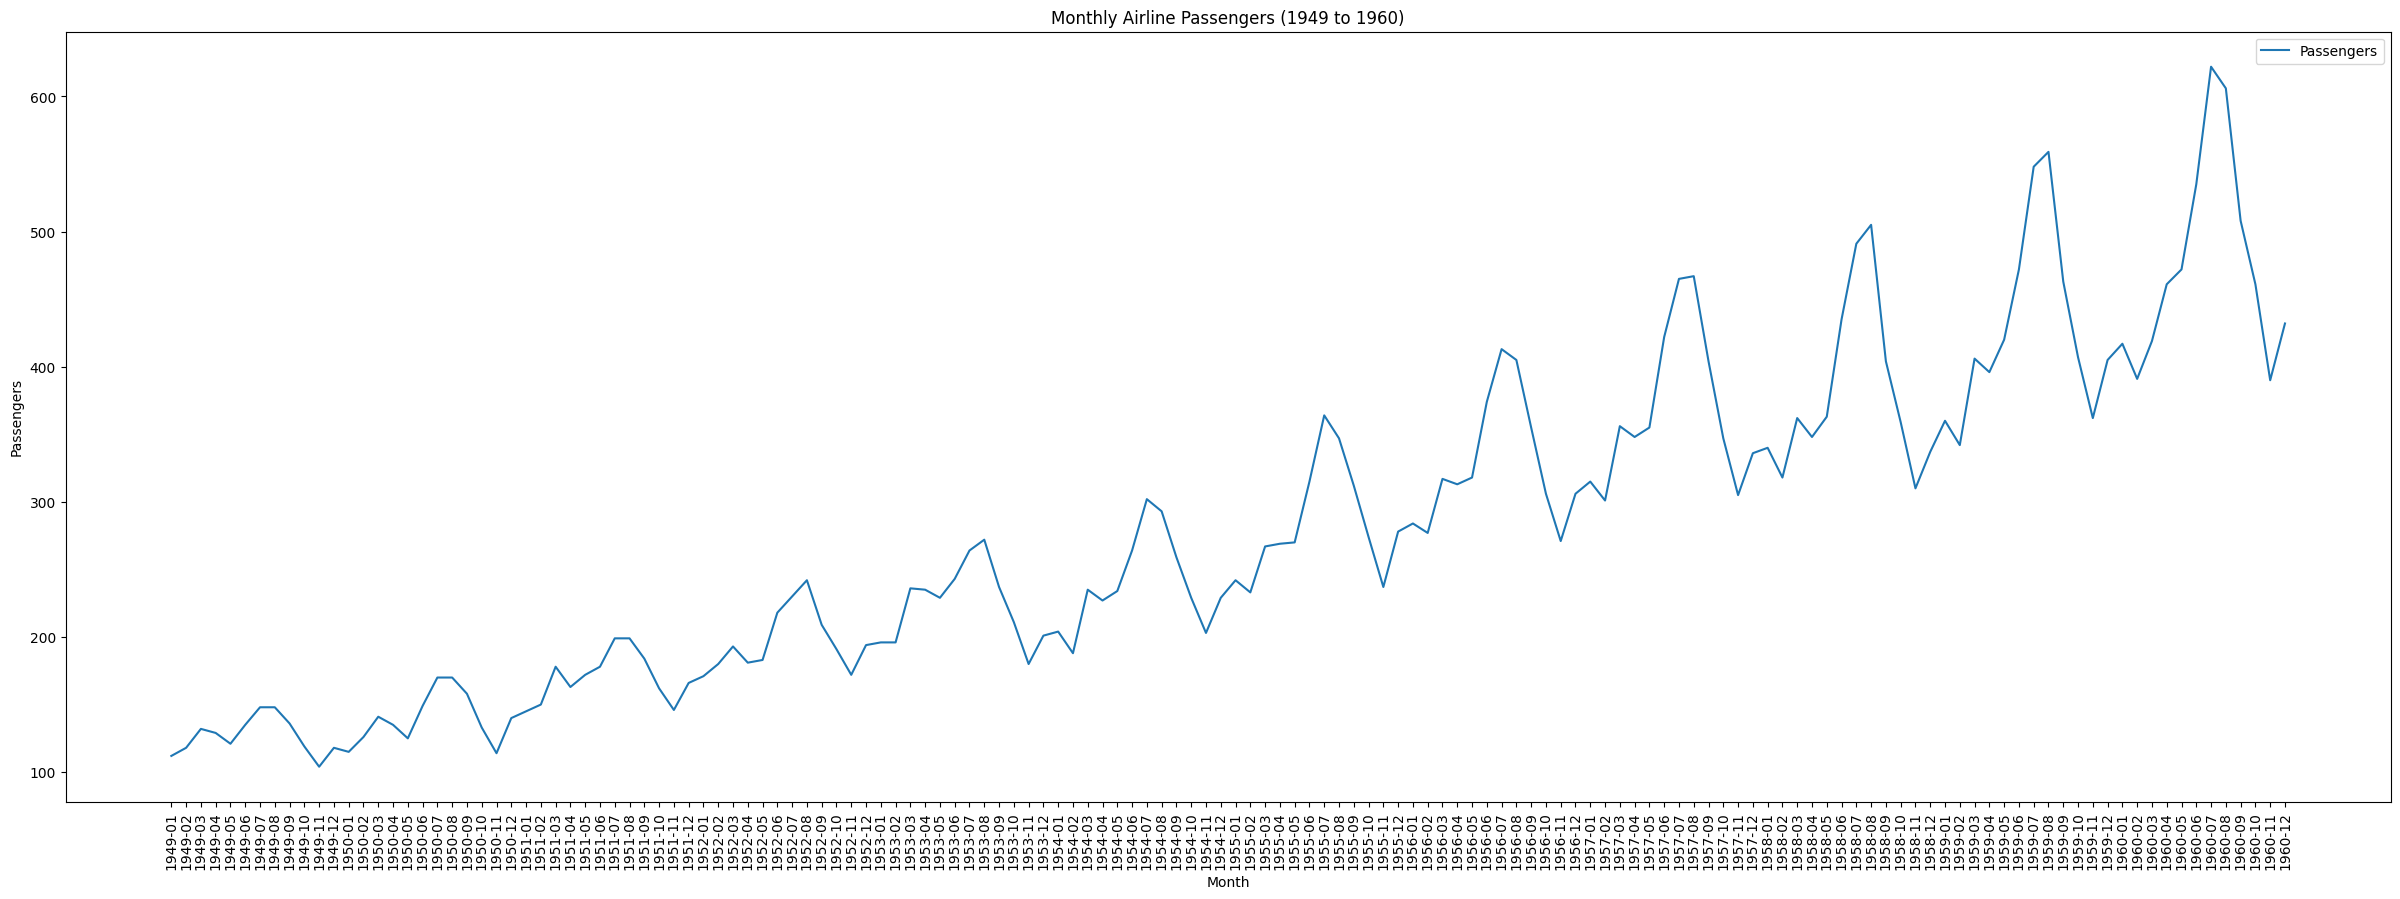

In [18]:
# plot time series
plt.figure(figsize=(30,10))
plt.plot(df["Month"], df["Passengers"], label="Passengers")
plt.title("Monthly Airline Passengers (1949 to 1960)")
plt.ylabel("Passengers")
plt.xlabel("Month")
plt.xticks(rotation="vertical")
plt.legend()
plt.show()

In [ ]:
# check for non-stationary (seasonal) data using Augmented Dickey-Fuller test (adfuller)
result = adfuller(df["Passengers"])
p_value = result[1]
adf_value = result[0]
print(f"p-value: {p_value:.3f}")
print(f"ADF Stat: {adf_value:.3f}")

p-value: 0.992
ADF Stat: 0.815


Null Hypothesis (H0) -> The data is non-stationary (seasonal)

Alternate Hypothesis (H1) -> The data is stationary (non-seasonal)

>Inference: The high p-value shows the series is non stationary, so transformations like differencing or decomposition are required before forecasting.

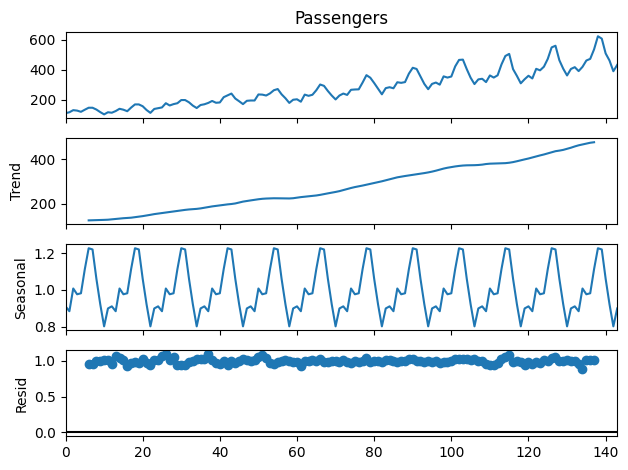

In [20]:
# seasonal decomposition
decomp = seasonal_decompose(
    df["Passengers"],
    model="multiplicative",
    period=12
)
decomp.plot()
plt.show()

In [21]:
# train test split
train = df.iloc[:-12]   # extract all the rows except last 12 rows
test = df.iloc[-12:]    # extract last 12 rows

In [22]:
train.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [23]:
test

,Month,Passengers
132,1960-01,417
133,1960-02,391
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461


In [24]:
# train ARIMA model
model = ARIMA(train["Passengers"], order=(5,1,0))
trained_model = model.fit()

In [ ]:
# forecast
forecast = trained_model.forx`xecast(steps=12)

In [ ]:
print(forecast)

132    458.449443
133    479.570530
134    480.136848
135    456.665328
136    435.835309
137    431.734530
138    437.928972
139    448.935482
140    455.562127
141    454.628435
142    450.095385
143    445.706018
Name: predicted_mean, dtype: float64


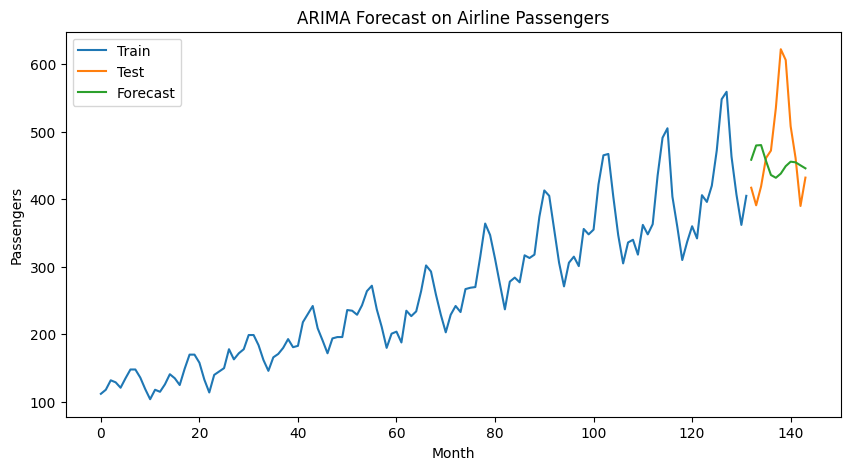

In [29]:
# plot forecast vs actual
plt.figure(figsize=(10,5))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.title("ARIMA Forecast on Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [31]:
# error metric
mae = mean_absolute_error(test['Passengers'], forecast)
mse = mean_squared_error(test['Passengers'], forecast)
rmse = root_mean_squared_error(test['Passengers'], forecast)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 67.39
MSE: 7536.00
RMSE: 86.81


In [42]:
# SARIMAX 
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [43]:
train_log = np.log(train["Passengers"])
test_log = np.log(test["Passengers"])

In [44]:
sarimax_model = SARIMAX(
    train_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

# train the model
trained_sarimax_model = sarimax_model.fit(disp=False, maxiter=200)

In [45]:
forecast_log = trained_sarimax_model.forecast(steps=12)
forecast_sarimax = np.exp(forecast_log)

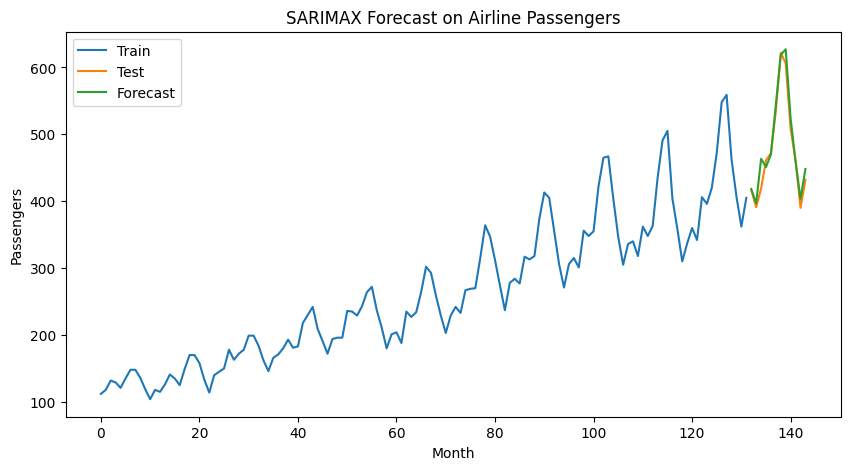

In [47]:
# plot forecast vs actual
plt.figure(figsize=(10,5))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, forecast_sarimax, label='Forecast')
plt.title("SARIMAX Forecast on Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [48]:
# error metric
mae = mean_absolute_error(test['Passengers'], forecast_sarimax)
mse = mean_squared_error(test['Passengers'], forecast_sarimax)
rmse = root_mean_squared_error(test['Passengers'], forecast_sarimax)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 11.99
MSE: 277.26
RMSE: 16.65


**ARIMA**

Full form: AutoRegressive Integrated Moving Average

One-liner: Predicts future values by removing trend and learning from past values and past errors.

(P, D, Q)
- P → past values used
- D → trend removal
- Q → past errors used

⸻

**SARIMAX**

Full form: Seasonal AutoRegressive Integrated Moving Average with eXogenous variables

One-liner: ARIMA extended to learn repeating seasonal patterns and optional external inputs.

Seasonal (P, D, Q, S)
- P, D, Q → seasonal memory and corrections
- S → season length (12 for monthly data)

⸻

Quick rule
- ARIMA → no seasonality
- SARIMAX → seasonality present